In [1]:
import os, random, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split


In [2]:
#max_in_class = 200
#train_part = 0.5
#noise = 0.1
batch_size = 100

epochs = 20
initial_lr = 0.002

device = "cpu"

60000 10000


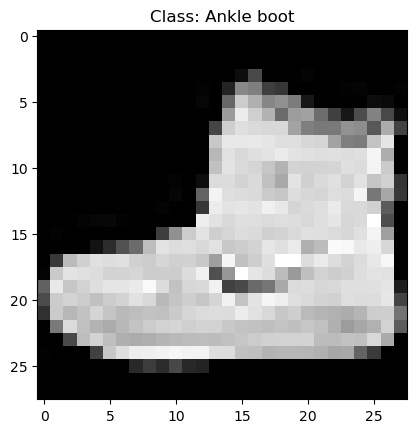

In [3]:
fashion_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

dataset_train = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=True, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)
dataset_test = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=False, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)

train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=1, shuffle=True)

print(len(train_dataloader.dataset), len(test_dataloader.dataset))

# Визуализация с подписью класса
plt.imshow(dataset_train[0][0].squeeze(), cmap='gray')
plt.title(f"Class: {fashion_classes[dataset_train[0][1]]}")
plt.show()

#for batch in dataloader:
#    print("Batch Data:", batch[0])  
#    print("Batch Labels:", batch[1])

100%|██████████| 10000/10000 [00:00<00:00, 10752.31it/s]


Train samples: 54000, Test samples: 9000


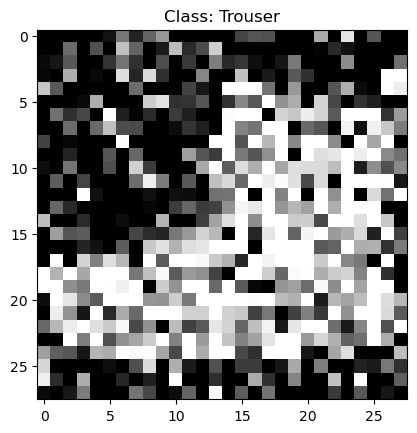

In [4]:
# Классы одежды и обуви (индексы в fashion_classes)
clothes_classes = [0, 1, 2, 3, 4, 6]  # 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Shirt'
shoes_classes = [5, 7, 9]             # 'Sandal', 'Sneaker', 'Ankle boot'
exclude_class = 8                     # 'Bag'

def filter_and_relabel(dataset):
    data = []
    targets = []
    for img, label in tqdm(dataset):
        if label == exclude_class:
            continue
        elif label in clothes_classes:
            data.append(img)
            targets.append(0)  # 0 - одежда
        elif label in shoes_classes:
            data.append(img)
            targets.append(1)  # 1 - обувь
    data = torch.stack(data)
    targets = torch.tensor(targets)
    return data, targets

def add_noise(images, noise_level=0.1):
    """
    Добавляет гауссовский шум к изображениям.
    images: torch.Tensor, shape (N, 1, 28, 28)
    noise_level: float, стандартное отклонение шума
    """
    noisy_images = images + noise_level * torch.randn_like(images)
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images


train_data, train_targets = filter_and_relabel(dataset_train)
test_data, test_targets = filter_and_relabel(dataset_test)

class FashionBinaryDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

train_data_noisy = add_noise(train_data, noise_level=0.5)
test_data_noisy = add_noise(test_data, noise_level=0.5)

binary_train_dataset = FashionBinaryDataset(train_data_noisy, train_targets)
binary_test_dataset = FashionBinaryDataset(test_data_noisy, test_targets)

binary_train_dataloader = DataLoader(binary_train_dataset, batch_size=batch_size, shuffle=True)
binary_test_dataloader = DataLoader(binary_test_dataset, batch_size=1, shuffle=True)

print(f"Train samples: {len(binary_train_dataset)}, Test samples: {len(binary_test_dataset)}")

plt.imshow(binary_train_dataset[0][0].squeeze(), cmap='gray')
plt.title(f"Class: {fashion_classes[binary_train_dataset[0][1]]}")
plt.show()

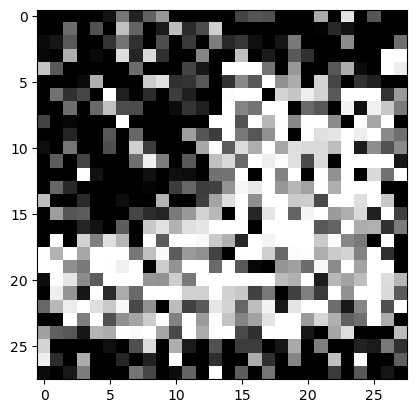

In [5]:
plt.imshow(binary_train_dataset[0][0].reshape(28, 28), cmap='gray')#черно-белое изображение

In [6]:
pd.set_option('display.max_columns', 28)
pd.DataFrame(binary_train_dataset[0][0].reshape(28, 28))#изображение в виде матрицы

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.077717,0.461192,0.134952,0.388362,0.593067,0.000000,0.000000,0.000000,0.000000,0.000000,0.268778,0.332650,0.319995,0.000000,0.000000,0.000000,0.665925,0.000000,0.894003,0.000000,0.336547,0.000000,0.000000
1,0.000000,0.000000,0.420311,0.000000,0.317894,0.000000,0.752084,0.388748,0.000000,0.103836,0.738106,0.167524,0.296606,0.811653,0.003663,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018533,0.158283,0.069151,0.000000,0.000000,0.000000,0.000000
2,0.041934,0.087786,0.345346,0.000000,0.000000,0.201014,0.449936,0.188391,0.000000,0.305981,0.000000,0.221967,0.000000,0.490549,0.157954,0.211874,0.061507,0.000000,0.083731,0.475873,0.000000,0.000000,0.000000,0.548272,0.000000,0.000000,0.000000,0.434939
3,0.028812,0.000000,0.681849,0.000000,0.038502,0.000000,0.865299,0.142083,0.853750,0.184656,0.000000,0.000000,0.527124,0.000000,0.000000,0.754420,0.000000,0.105994,0.000000,0.345300,0.192678,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
4,0.771193,0.352756,0.000000,0.000000,0.000000,0.000000,0.000000,0.424658,0.000000,0.000000,0.000000,0.265061,0.092892,0.000000,1.000000,1.000000,1.000000,0.449757,0.000000,0.596476,0.000000,0.000000,0.338726,0.677023,0.050444,0.000000,1.000000,0.925979
5,0.000000,0.000000,0.000000,0.038594,0.680624,0.000000,0.000000,0.000000,0.800651,0.875126,0.189815,0.199519,0.338054,0.000000,0.197856,0.534543,0.346662,1.000000,0.569046,0.673750,0.000000,0.820559,0.276035,0.000000,0.197412,0.132208,0.000000,0.000000
6,0.000000,0.448916,0.188953,0.276846,0.000000,1.000000,0.131430,0.011777,0.170429,0.000000,0.240385,0.124964,0.000000,0.000000,0.981807,1.000000,1.000000,0.000000,0.830739,0.774646,0.929753,0.820683,0.347995,1.000000,1.000000,1.000000,0.202268,0.608571
7,0.000000,0.000000,0.427850,0.000000,0.414406,0.748941,0.304460,0.295607,0.000000,0.000000,0.049878,0.210725,0.130916,0.000000,1.000000,0.515593,0.451919,1.000000,1.000000,0.000000,0.415601,0.337782,0.000000,0.956362,0.059068,0.937558,0.779055,0.483430
8,0.262609,0.000000,0.025840,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.326147,1.000000,0.715657,1.000000,0.533224,1.000000,1.000000,0.543052,0.000000,1.000000,0.648961,1.000000,0.000000
9,0.000000,0.000000,0.143883,0.000000,0.000000,0.336204,0.000000,0.405114,0.000000,0.000000,0.000000,0.620728,0.332164,0.238118,1.000000,0.476565,0.337059,0.564110,1.000000,0.001086,1.000000,0.871270,0.900506,1.000000,0.930579,1.000000,0.538948,0.435844


In [7]:
MP1 = nn.MaxPool2d(kernel_size=2, stride= 2)
pd.set_option('display.max_columns', 14)
tmp_MP1 = MP1(binary_train_dataset[0][0])
pd.DataFrame(tmp_MP1.reshape(14, 14))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.000000,0.420311,0.317894,0.752084,0.593067,0.738106,0.811653,0.268778,0.332650,0.000000,0.665925,0.894003,0.336547,0.000000
1,0.087786,0.681849,0.201014,0.865299,0.853750,0.221967,0.527124,0.754420,0.105994,0.475873,0.192678,0.548272,0.000000,1.000000
2,0.771193,0.038594,0.680624,0.424658,0.875126,0.265061,0.338054,1.000000,1.000000,0.673750,0.820559,0.677023,0.197412,1.000000
3,0.448916,0.427850,1.000000,0.304460,0.170429,0.240385,0.130916,1.000000,1.000000,1.000000,0.929753,1.000000,1.000000,0.779055
4,0.262609,0.143883,0.336204,1.000000,0.000000,0.620728,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,0.364362,0.458746,0.307245,0.814680,0.936308,0.346389,1.000000,0.861971,1.000000,0.984499,0.854035,1.000000,1.000000,1.000000
6,0.399187,1.000000,0.067247,0.000000,0.065260,0.401986,0.447874,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,0.745451,0.362658,0.000000,0.271087,0.699888,0.598155,0.826994,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,0.831914,0.871867,0.714741,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.688153,1.000000
9,1.000000,1.000000,1.000000,1.000000,0.974303,0.996515,1.000000,1.000000,1.000000,0.982534,0.995920,1.000000,1.000000,1.000000


In [8]:
pd.set_option('display.max_columns', 7)
pd.DataFrame(MP1(tmp_MP1).reshape(7, 7))

,0,1,2,3,4,5,6
0,0.681849,0.865299,0.853750,0.811653,0.475873,0.894003,1.000000
1,0.771193,1.000000,0.875126,1.000000,1.000000,1.000000,1.000000
2,0.458746,1.000000,0.936308,1.000000,1.000000,1.000000,1.000000
3,1.000000,0.271087,0.699888,1.000000,1.000000,1.000000,1.000000
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,0.936132,1.000000,1.000000,1.000000,1.000000,0.866143,0.980965


In [9]:
MP2 = nn.MaxPool2d(kernel_size=2, stride= 1)
pd.set_option('display.max_columns', 13)
pd.DataFrame(MP2(tmp_MP1).reshape(13, 13))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.681849,0.681849,0.865299,0.865299,0.853750,0.811653,0.811653,0.75442,0.475873,0.665925,0.894003,0.894003,1.000000
1,0.771193,0.681849,0.865299,0.875126,0.875126,0.527124,1.000000,1.00000,1.000000,0.820559,0.820559,0.677023,1.000000
2,0.771193,1.000000,1.000000,0.875126,0.875126,0.338054,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.448916,1.000000,1.000000,1.000000,0.620728,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.458746,0.458746,1.000000,1.000000,0.936308,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
5,1.000000,1.000000,0.814680,0.936308,0.936308,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
6,1.000000,1.000000,0.271087,0.699888,0.699888,0.826994,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
7,1.000000,0.871867,0.871867,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 2) 
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.softmax(x, dim=1) 
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [11]:
model = SimpleNN()
summary(model, (1, 28, 28), batch_size, device = device)
print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [100, 512]         401,920
       BatchNorm1d-2                 [100, 512]           1,024
            Linear-3                 [100, 256]         131,328
       BatchNorm1d-4                 [100, 256]             512
           Dropout-5                 [100, 256]               0
            Linear-6                   [100, 2]             514
Total params: 535,298
Trainable params: 535,298
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.30
Forward/backward pass size (MB): 1.37
Params size (MB): 2.04
Estimated Total Size (MB): 3.71
----------------------------------------------------------------
SimpleNN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2):

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [13]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [20]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(binary_train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(binary_test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 99.7%, Avg loss: 0.017106 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 99.7%, Avg loss: 0.015581 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 99.7%, Avg loss: 0.014220 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 99.7%, Avg loss: 0.015016 

Epoch 5
-------------------------------


KeyboardInterrupt: 

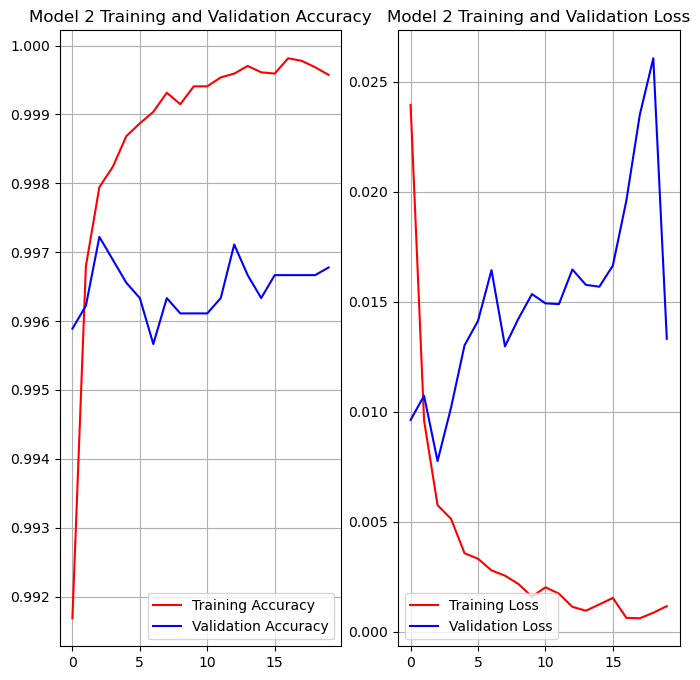

In [19]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Model 2 Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Model 2 Training and Validation Loss')
plt.grid()
plt.show()

In [16]:
model.eval()
cmt = torch.zeros(2, 2, dtype=torch.int32)  # Для бинарной классификации
with torch.no_grad():
    for X, y in binary_test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X)
        predicted = preds.argmax(dim=1)
        for true_label, pred_label in zip(y, predicted):
            cmt[true_label, pred_label] += 1

In [17]:
pd.set_option('display.max_columns', 2)
pd.DataFrame(cmt.numpy(), columns=['Pred: Clothes', 'Pred: Shoes'], index=['True: Clothes', 'True: Shoes'])

,Pred: Clothes,Pred: Shoes
True: Clothes,5979,21
True: Shoes,8,2992
